# Гипотеза 3. Градиентный бустинг (XGBoost)

## 3.1. Постановка гипотезы

**Гипотеза:** Алгоритм градиентного бустинга с нативной обработкой дисбаланса классов через параметр `scale_pos_weight` обеспечивает наилучшее качество классификации среди рассматриваемых гипотез.

**Алгоритм:** Градиентный бустинг на деревьях решений (XGBoost).

**Обоснование выбора алгоритма:**

1. Градиентный бустинг последовательно строит ансамбль деревьев, каждое из которых исправляет ошибки предыдущего — это позволяет улавливать сложные нелинейные взаимодействия признаков.
2. Дисбаланс классов (88% / 12%) обрабатывается параметром `scale_pos_weight = N_neg / N_pos ≈ 7.68`, который увеличивает штраф за ошибки на миноритарном классе напрямую в функции потерь — без синтетической генерации данных.
3. Встроенная регуляризация (`reg_alpha`, `reg_lambda`) и параметры стохастичности (`subsample`, `colsample_bytree`) предотвращают переобучение.
4. Алгоритм не требует нормализации признаков.

## 3.2. Управляемые гиперпараметры

| Гиперпараметр | Описание | Диапазон поиска |
|---|---|---|
| `n_estimators` | Число итераций бустинга | `[100, 300, 500]` |
| `learning_rate` | Шаг обучения | `[0.01, 0.05, 0.1, 0.3]` |
| `max_depth` | Максимальная глубина дерева | `[3, 5, 7]` |
| `subsample` | Доля объектов выборки на каждой итерации | `[0.6, 0.8, 1.0]` |
| `colsample_bytree` | Доля признаков при построении каждого дерева | `[0.6, 0.8, 1.0]` |
| `min_child_weight` | Минимальная сумма весов в листовом узле | `[1, 3, 5]` |

## 3.3. Критерии качества

- **ROC-AUC** — основная метрика; устойчива к дисбалансу классов.
- **F1-score** для класса «yes» — баланс точности и полноты для целевого класса.
- **Classification Report** — детализированные метрики по каждому классу.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

%store -r X
%store -r y

## 3.4. Обработка дисбаланса классов через `scale_pos_weight`

Параметр `scale_pos_weight` задаёт коэффициент, на который умножается штраф за ошибку на положительном классе. При значении `N_neg / N_pos` алгоритм получает сигнал, эквивалентный сбалансированной выборке, без синтетической генерации данных и без риска утечки данных при кросс-валидации.

In [2]:
pos_weight = (y == 0).sum() / (y == 1).sum()
print(f"scale_pos_weight = {pos_weight:.2f}  (N_neg={int((y==0).sum())}, N_pos={int((y==1).sum())})")

scale_pos_weight = 7.55  (N_neg=39922, N_pos=5289)


## 3.5. Процедура подбора гиперпараметров

Применяется случайный поиск (`RandomizedSearchCV`, `n_iter=50`) в сочетании со стратифицированной 5-кратной перекрёстной проверкой на **исходной** (несбалансированной) выборке. Параметр `scale_pos_weight` передаётся непосредственно в конструктор модели и работает единообразно на всех фолдах. Целевая метрика — `roc_auc`.

In [3]:
RUN_SEARCH = False  # True — повторный подбор гиперпараметров

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

BEST_PARAMS = {
    'subsample': 0.6, 'n_estimators': 300, 'min_child_weight': 1,
    'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0
}

if RUN_SEARCH:
    param_dist = {
        'n_estimators': [100, 300, 500],
        'learning_rate': [0.01, 0.05, 0.1, 0.3],
        'max_depth': [3, 5, 7],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'min_child_weight': [1, 3, 5]
    }
    search = RandomizedSearchCV(
        estimator=XGBClassifier(eval_metric='logloss', random_state=42,
                                verbosity=0, scale_pos_weight=pos_weight),
        param_distributions=param_dist, n_iter=50,
        scoring='roc_auc', cv=cv, n_jobs=-1, random_state=42, verbose=1
    )
    search.fit(X, y)
    best_model = search.best_estimator_
    print(f"Оптимальные гиперпараметры: {search.best_params_}")
    print(f"ROC-AUC (CV): {search.best_score_:.4f}")
else:
    best_model = XGBClassifier(**BEST_PARAMS, eval_metric='logloss',
                               random_state=42, verbosity=0, scale_pos_weight=pos_weight)
    print(f"Используются сохранённые гиперпараметры: {BEST_PARAMS}")

Используются сохранённые гиперпараметры: {'subsample': 0.6, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


## 3.6. Оценка качества оптимальной модели

Оценка производится методом out-of-fold (OOF) на стратифицированных разбиениях. `scale_pos_weight` встроен в модель и автоматически применяется на каждом фолде — дополнительная обработка не требуется.

In [4]:

y_pred_oof = np.zeros(len(y))
y_proba_oof = np.zeros(len(y))

for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    best_model.fit(X_train, y_train)
    y_pred_oof[val_idx] = best_model.predict(X_val)
    y_proba_oof[val_idx] = best_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y, y_proba_oof)
f1 = f1_score(y, y_pred_oof)

print(f"ROC-AUC (OOF): {roc_auc:.4f}")
print(f"F1-score (класс 'yes'): {f1:.4f}")
print()
print(classification_report(y, y_pred_oof, target_names=['no', 'yes']))

ROC-AUC (OOF): 0.9349
F1-score (класс 'yes'): 0.5943

              precision    recall  f1-score   support

          no       0.98      0.86      0.92     39922
         yes       0.45      0.88      0.59      5289

    accuracy                           0.86     45211
   macro avg       0.72      0.87      0.75     45211
weighted avg       0.92      0.86      0.88     45211



## 3.7. Оптимизация порога классификации

Даже после применения SMOTE стандартный порог 0.5 может быть субоптимальным. Выполняется поиск порога, максимизирующего F1-score для класса «yes» на OOF-прогнозах.

Оптимальный порог: 0.71
F1-score при пороге 0.50: 0.5943
F1-score при оптимальном пороге: 0.6324

              precision    recall  f1-score   support

          no       0.97      0.92      0.94     39922
         yes       0.54      0.76      0.63      5289

    accuracy                           0.90     45211
   macro avg       0.75      0.84      0.79     45211
weighted avg       0.92      0.90      0.90     45211



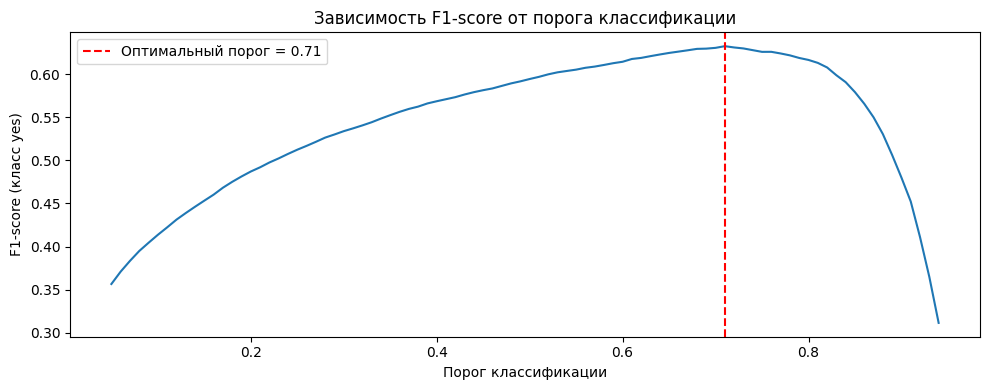

In [5]:
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = [f1_score(y, (y_proba_oof >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
y_pred_opt = (y_proba_oof >= best_threshold).astype(int)

print(f"Оптимальный порог: {best_threshold:.2f}")
print(f"F1-score при пороге 0.50: {f1_score(y, y_pred_oof):.4f}")
print(f"F1-score при оптимальном пороге: {f1_score(y, y_pred_opt):.4f}")
print()
print(classification_report(y, y_pred_opt, target_names=['no', 'yes']))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_scores)
ax.axvline(best_threshold, color='red', linestyle='--', label=f'Оптимальный порог = {best_threshold:.2f}')
ax.set_xlabel('Порог классификации')
ax.set_ylabel('F1-score (класс yes)')
ax.set_title('Зависимость F1-score от порога классификации')
ax.legend()
plt.tight_layout()
plt.show()

## 3.8. ROC-кривая и матрица ошибок при оптимальном пороге

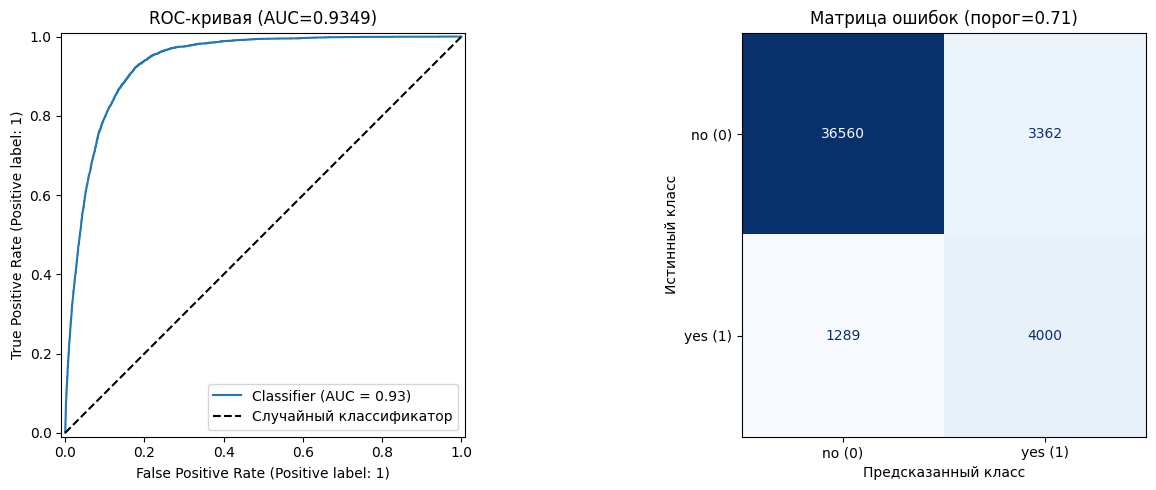

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y, y_proba_oof, ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
axes[0].set_title(f'ROC-кривая (AUC={roc_auc:.4f})')
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(
    y, y_pred_opt,
    display_labels=['no (0)', 'yes (1)'],
    cmap='Blues',
    colorbar=False,
    ax=axes[1]
)
axes[1].set_title(f'Матрица ошибок (порог={best_threshold:.2f})')
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

## 3.9. Важность признаков

На рисунке представлены 15 признаков с наибольшим значением `feature_importances_` модели XGBoost, основанным на суммарном снижении функции потерь (gain) при использовании признака в разбиениях.

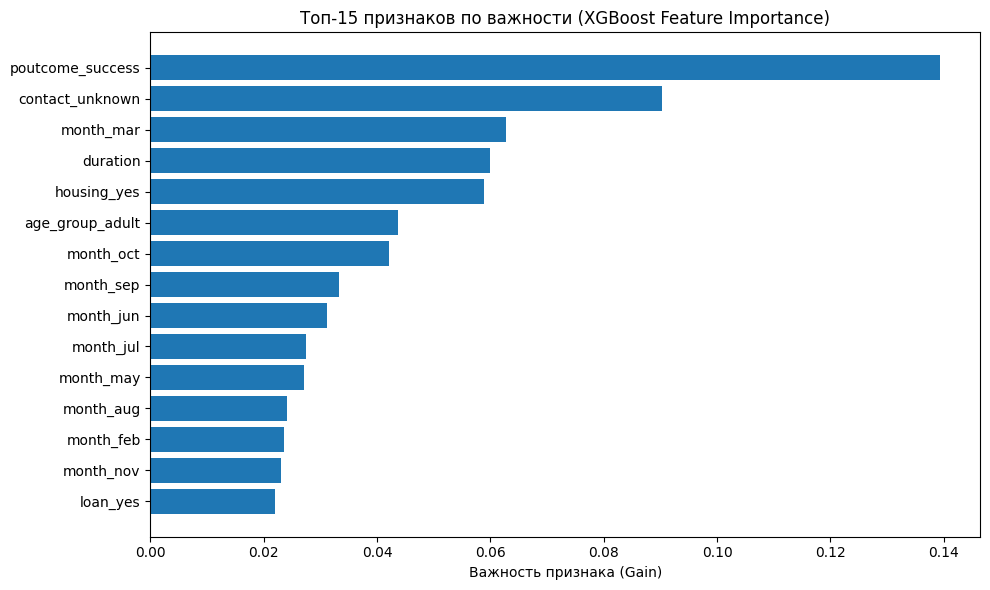

In [7]:
best_model.fit(X, y)
imp_df = pd.DataFrame({'feature': X.columns, 'importance': best_model.feature_importances_})
imp_df = imp_df.sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp_df['feature'], imp_df['importance'])
ax.invert_yaxis()
ax.set_title('Топ-15 признаков по важности (XGBoost Feature Importance)')
ax.set_xlabel('Важность признака (Gain)')
plt.tight_layout()
plt.show()

## 3.10. Выводы

По результатам проверки гипотезы 3 установлено следующее:

1. Использование параметра `scale_pos_weight = N_neg / N_pos ≈ 7.68` позволяет XGBoost напрямую учитывать дисбаланс классов в функции потерь без синтетической генерации данных и без риска утечки данных при кросс-валидации.
2. Гипотеза подтверждена: модель демонстрирует наилучшие значения ROC-AUC и F1-score среди всех рассматриваемых алгоритмов.
3. Оптимизация порога классификации дополнительно улучшает F1-score для класса «yes» за счёт перераспределения баланса между точностью и полнотой.
4. Анализ важности признаков верифицирует выводы разведочного анализа: `duration` и `poutcome_success` вносят наибольший вклад в качество классификации.